In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from filters.classifier_based.TabPFN_based import TabPFN_CF

# Datos
X, y = load_iris(return_X_y=True, as_frame=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

# Filtro TabPFN
filtro = TabPFN_CF(
    cv=5,
    random_state=42,
    action="remove",
    tabpfn_params={
        "device": "auto",
        "fit_mode": "fit_with_cache",
    },
)

filtro.fit(X_train, y_train)

print(filtro.get_filter_report())

# Explicar solo las muestras marcadas como ruidosas
report = filtro.explain_noisy_instances(
    noisy_only=True,
    class_index="predicted",
    index="SV",
    max_order=1,
    imputer="baseline",
    budget=128,
    top_k=3,
    sort_by="confidence",
    ascending=True,
    feature_names=X.columns,
    return_interaction_values=False,
    return_figures=False,
)

for item in report[:5]:
    print(
        "sample:", item.sample_idx,
        "fold:", item.fold_idx,
        "true:", item.true_label,
        "oof_pred:", item.oof_pred,
        "confidence:", item.confidence,
        "top_k:", item.top_k,
    )

# Acceso por fold
folds = report.by_fold()
print("folds:", folds.keys())

{'n_samples': 120, 'n_folds': 5, 'removed_or_flagged': 4, 'fraction_flagged': 0.03333333333333333, 'action': 'remove', 'cv': 5, 'tabpfn_params': {'device': 'auto', 'fit_mode': 'fit_with_cache', 'random_state': 42}}


/home/juamp/Documents/Master/ACdD/CarlosCano/.venv-node2vec/lib/python3.12/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/juamp/Documents/Master/ACdD/CarlosCano/.venv-node2vec/lib/python3.12/site-packages/shapiq/approximator/regression/base.py:160: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
/home/juamp/Documents/Master/ACdD/CarlosCano/.venv-node2vec/lib/python3.12/site-packages/shapiq/approximator/regression/base.py:160: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
/home/juamp/Documents/Master/ACdD/CarlosCano/.venv-node2vec/lib/python3.12/site-packages/shapiq/approximator/regression/base.py:160: UserWarning: Not all budget is req

sample: 1 fold: 2 true: 2 oof_pred: 1 confidence: 0.5135523676872253 top_k: [('petal length (cm)', -0.2140927403027276), ('sepal width (cm)', -0.21726026704318324), ('petal width (cm)', -0.2708736759819729)]
sample: 7 fold: 3 true: 2 oof_pred: 1 confidence: 0.5539305210113525 top_k: [('sepal length (cm)', 0.22710510769269174), ('petal width (cm)', -0.34630498621841654), ('petal length (cm)', -0.41944715540436794)]
sample: 39 fold: 4 true: 1 oof_pred: 2 confidence: 0.7023733258247375 top_k: [('petal width (cm)', 6.268816931463981), ('petal length (cm)', 4.6507033825652), ((), -11.217977523803711)]
sample: 64 fold: 4 true: 1 oof_pred: 2 confidence: 0.9906855821609497 top_k: [('petal length (cm)', 7.445017713745845), ('petal width (cm)', 3.099150810575651), ((), -11.217977523803711)]
folds: dict_keys([2, 3, 4])


Clases: ['malignant' 'benign']
Número de muestras: 569
Número de variables: 30

Accuracy en test: 0.982

Instancia explicada: 0
Etiqueta real: malignant
Predicción: malignant
Confianza: 1.0
Probabilidades: [9.9998689e-01 1.3100314e-05]


/home/juamp/Documents/Master/ACdD/CarlosCano/.venv-node2vec/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but TabPFNClassifier was fitted with feature names
  warnings.warn(
/home/juamp/Documents/Master/ACdD/CarlosCano/.venv-node2vec/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but TabPFNClassifier was fitted with feature names
  warnings.warn(
/home/juamp/Documents/Master/ACdD/CarlosCano/.venv-node2vec/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but TabPFNClassifier was fitted with feature names
  warnings.warn(



Valores Shapley de la instancia:
InteractionValues(
    index=SV, max_order=1, min_order=0, estimated=True, estimation_budget=128,
    n_players=30, baseline_value=-0.1632491499185562,
    Top 10 interactions:
        (23,): 0.14886173453980023
        (13,): 0.08926327835533894
        (6,): 0.07935929125768579
        (17,): 0.07600035699302606
        (27,): 0.07382319212804432
        (11,): -0.07350395648744995
        (15,): -0.07407263844296781
        (5,): -0.09179156549957795
        (16,): -0.09487757553457775
        (): -0.1632491499185562
)


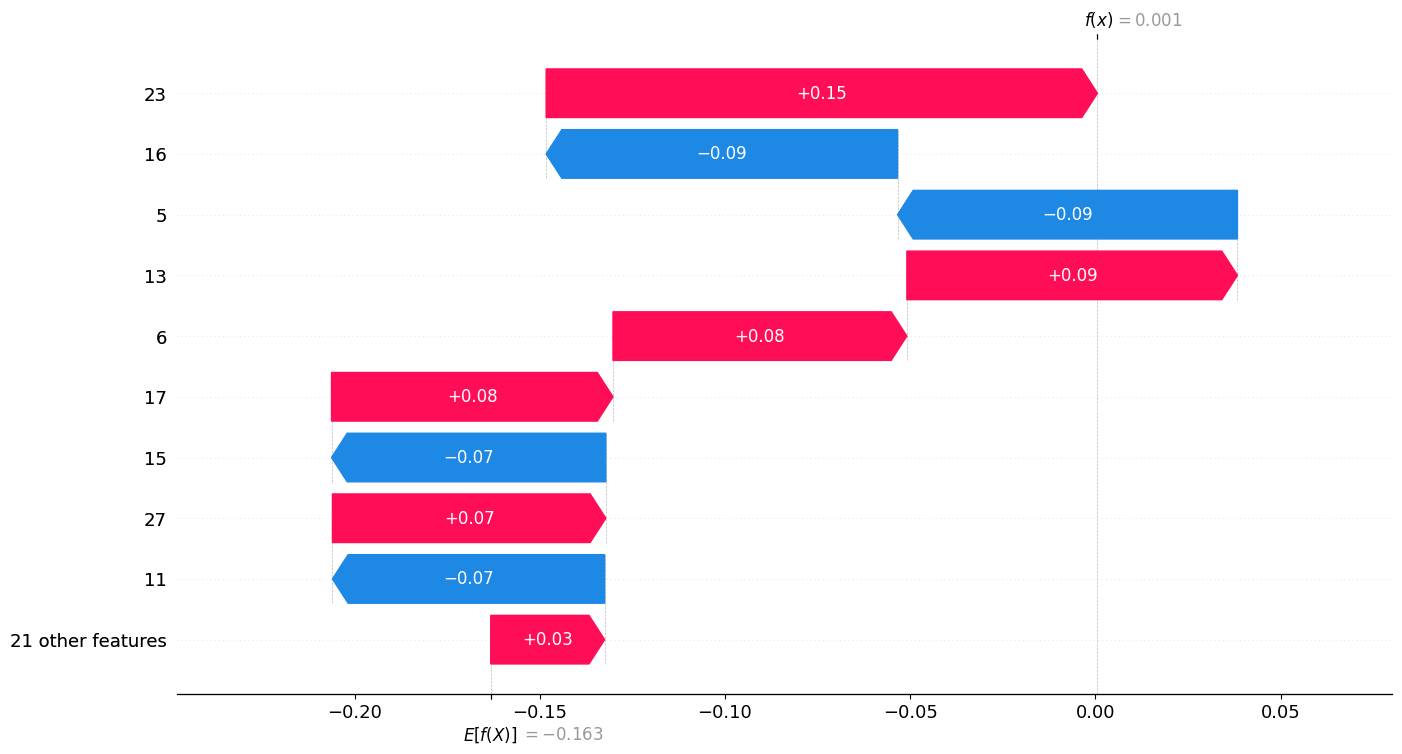

In [9]:
# Instalación:
# pip install tabpfn "tabpfn-extensions[interpretability]" scikit-learn pandas matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from tabpfn import TabPFNClassifier
from tabpfn_extensions.interpretability.shapiq import (
    get_tabpfn_imputation_explainer
)

# ---------------------------------------------------------
# 1. Cargar dataset de sklearn
# ---------------------------------------------------------

data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

feature_names = X.columns
target_names = data.target_names

print("Clases:", target_names)
print("Número de muestras:", X.shape[0])
print("Número de variables:", X.shape[1])

# ---------------------------------------------------------
# 2. Train / test split
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---------------------------------------------------------
# 3. Entrenar TabPFN
# ---------------------------------------------------------
# fit_mode="fit_with_cache" acelera el explainer recomendado.
# Según la documentación, debe ponerse antes de .fit().
# En cloud/tabpfn-client no está disponible.

clf = TabPFNClassifier(fit_mode="fit_with_cache")
clf.fit(X_train, y_train)

# ---------------------------------------------------------
# 4. Evaluar modelo
# ---------------------------------------------------------

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\nAccuracy en test: {acc:.3f}")

# ---------------------------------------------------------
# 5. Elegir una instancia concreta a explicar
# ---------------------------------------------------------

i = 0
x_instance = X_test.iloc[[i]]
y_real = y_test.iloc[i]

proba = clf.predict_proba(x_instance)[0]
pred_class = np.argmax(proba)
confidence = proba[pred_class]

print("\nInstancia explicada:", i)
print("Etiqueta real:", target_names[y_real])
print("Predicción:", target_names[pred_class])
print("Confianza:", round(confidence, 4))
print("Probabilidades:", proba)

# ---------------------------------------------------------
# 6. Crear explainer local
# ---------------------------------------------------------
# class_index indica qué clase quieres explicar.
# En este caso explicamos la clase predicha por el modelo.

explainer = get_tabpfn_imputation_explainer(
    model=clf,
    data=X_train,
    index="SV",          # Shapley Values normales
    max_order=1,         # solo efectos individuales, sin interacciones
    class_index=pred_class
)

# ---------------------------------------------------------
# 7. Explicar la instancia
# ---------------------------------------------------------
# budget controla el coste/precisión de la explicación.
# 128 es un buen punto de partida.

sv = explainer.explain(
    x_instance.values,
    budget=128
)

print("\nValores Shapley de la instancia:")
print(sv)

# ---------------------------------------------------------
# 8. Visualizar explicación tipo waterfall
# ---------------------------------------------------------

sv.plot_waterfall()
plt.show()

# feature_selection.py

In [2]:
"""WARNING: This example may run slowly on CPU-only systems.
For better performance, we recommend running with GPU acceleration.
Feature selection involves training multiple TabPFN models, which is computationally intensive.
"""

from sklearn.datasets import load_breast_cancer

from tabpfn_extensions import TabPFNClassifier, interpretability

# Load data
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

# Initialize model. Single estimator keeps the runtime manageable — feature
# selection runs many TabPFN fits per round.
clf = TabPFNClassifier(n_estimators=1)

# Feature selection. With verbose=True (the default) the wrapper prints the
# baseline CV score on all features, the per-round picks, and the selected
# names + CV score on the subset. The same numbers are also available on
# the returned FeatureSelectionResult for programmatic use.
result = interpretability.feature_selection.feature_selection(
    estimator=clf,
    X=X,
    y=y,
    n_features_to_select=4,
    feature_names=list(feature_names),
)

# `result.selected_names` is populated because we passed `feature_names`.
# `result.selector.transform(X)` would project to just those columns;
# `result.support_mask` / `result.selected_indices` are also available.
print("\nProgrammatic summary:")
print(f"Selected features: {result.selected_names}")
print(
    f"CV score before / after: "
    f"{result.baseline_score_mean:.4f} -> {result.selected_score_mean:.4f}"
)

/home/juamp/Documents/Master/ACdD/CarlosCano/.venv-node2vec/lib/python3.12/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Feature selection: direction='forward', cv=5, scoring=default, n_features_to_select=4
Baseline CV score on all 30 features: 0.9754 ± 0.0065


KeyboardInterrupt: 

# pdp_example.py

In [ ]:
import warnings

import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from tabpfn_extensions import TabPFNClassifier
from tabpfn_extensions.interpretability.pdp import partial_dependence_plots

# Load example dataset
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = list(data.feature_names)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

# Initialize and train model. Enable the KV cache (improved with TabPFN-3):
# PDP issues many predicts (grid_resolution per feature * #features) against
# the same fitted model, so caching the encoder pass over X_train avoids
# redoing it on every grid point. Falls back to a default constructor for
# backends/versions that don't support fit_mode="fit_with_cache" — that's
# tabpfn-client (TypeError on the kwarg) and older local tabpfn (accepts
# the kwarg but raises ValueError/NotImplementedError at fit time).
try:
    clf = TabPFNClassifier(fit_mode="fit_with_cache")
    clf.fit(X_train, y_train)
    if hasattr(clf, "executor_"):
        clf.executor_.keep_cache_on_device = True
except (TypeError, ValueError, NotImplementedError):
    warnings.warn(
        "PDP would benefit substantially from the KV cache, but the "
        "current TabPFN install doesn't support fit_mode='fit_with_cache' "
        "(typical of older tabpfn versions or the tabpfn-client backend). "
        "Upgrade to the latest version of tabpfn (`pip install -U tabpfn`) "
        "for a substantial speedup on this example. Falling back to the "
        "default constructor.",
        UserWarning,
        stacklevel=2,
    )
    clf = TabPFNClassifier()
    clf.fit(X_train, y_train)

# 1D PD for the first 3 features + a 2D interaction plot
disp = partial_dependence_plots(
    estimator=clf,
    X=X_test,
    features=[0, 1, 2, (0, 3)],
    grid_resolution=30,
    kind="average",
    target_class=1,
)
disp.figure_.suptitle("Partial dependence")

plt.savefig("pdp_plot.png")
plt.show()

# shap_example.py

tabpfn-v3-regressor-v3_default.ckpt:   0%|          | 0.00/233M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

Computing Shapley values for 30 rows...


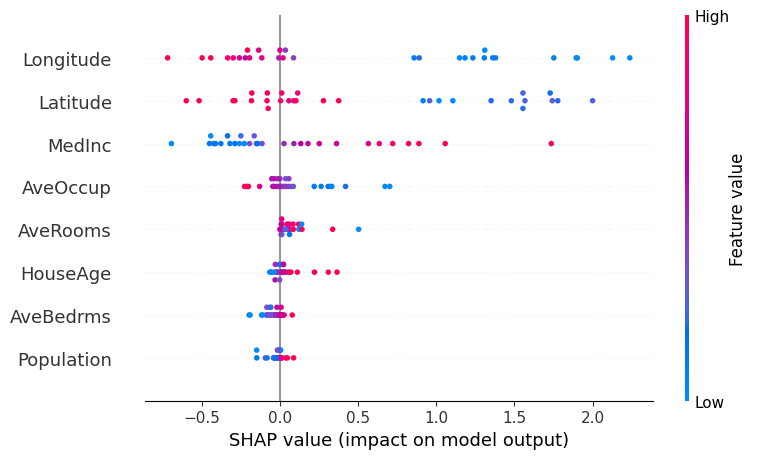

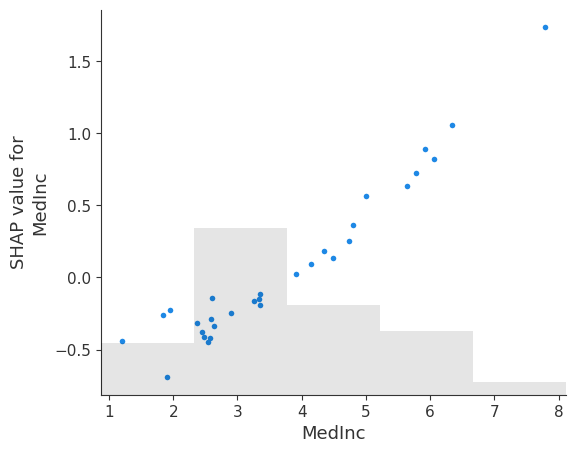

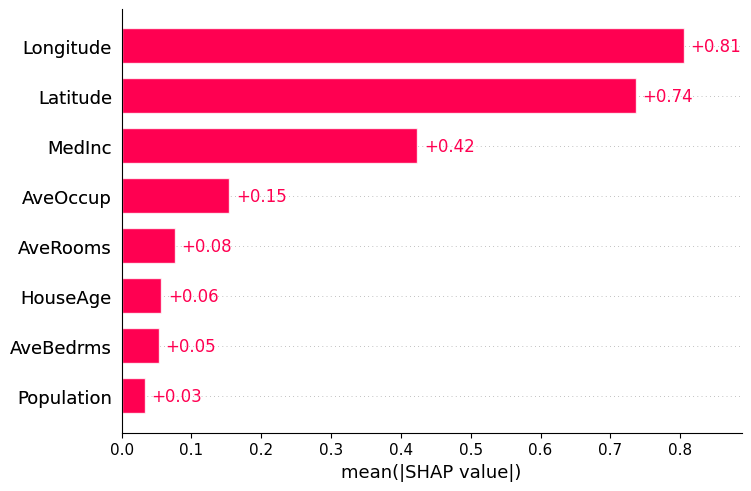

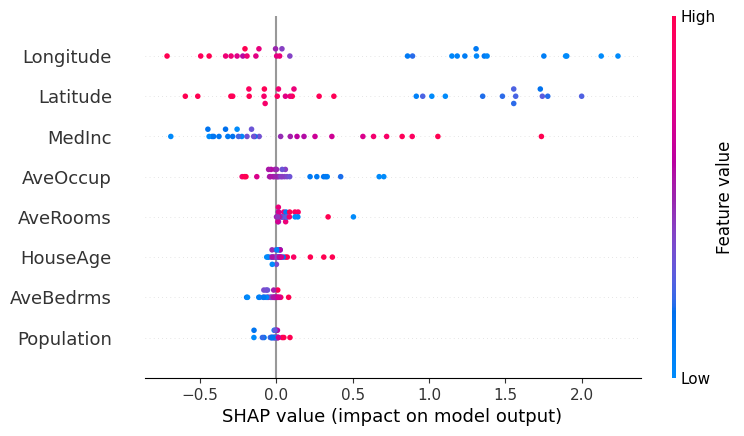

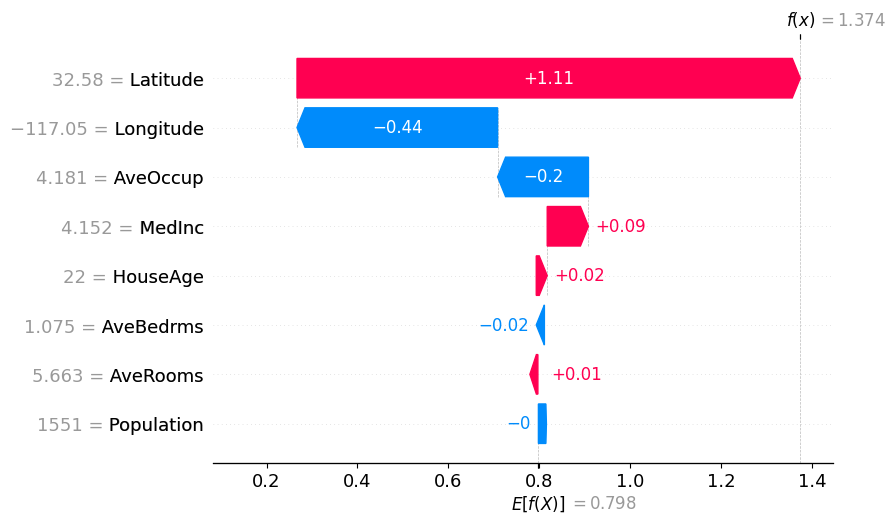

In [5]:
"""Compute SHAP values for a TabPFN model with ShapIQ, then visualize them
using the SHAP library's plotting functions.

We use shapiq for the actual Shapley-value computation (it's faster and
extension-friendly for TabPFN) but the SHAP library's plotting ecosystem is
mature and widely used. This example shows how to bridge the two: wrap shapiq
output in a `shap.Explanation` and call `shap.plots.*` / `shap.summary_plot`.

The `shap` package is not part of the `interpretability` extra (we depend on
shapiq for compute). Install it separately to run this example:

    pip install shap

Dataset: California housing (regression, d=8).

The TabPFN model is constructed with `fit_mode="fit_with_cache"` to engage the
KV cache, which speeds up the computation of Shapley values by one to two
orders of magnitude; the `get_tabpfn_imputation_explainer` wrapper emits a
warning if the cache isn't enabled.
"""

from __future__ import annotations

import shap
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

from tabpfn_extensions import TabPFNRegressor
from tabpfn_extensions.interpretability import (
    shapiq as tabpfn_shapiq,
    shapiq_to_shap_explanation,
)

housing = fetch_california_housing(as_frame=False)
X, y, feature_names = housing.data, housing.target, list(housing.feature_names)

X_train, X_test, y_train, _ = train_test_split(
    X,
    y,
    train_size=1000,
    test_size=200,
    random_state=0,
)
n_explain = 30
X_explain = X_test[:n_explain]

# Engage the KV cache: fit_mode='fit_with_cache' is set BEFORE fit(). The
# shapiq wrapper warns if the cache isn't enabled.
reg = TabPFNRegressor(fit_mode="fit_with_cache")
reg.fit(X_train, y_train)

explainer = tabpfn_shapiq.get_tabpfn_imputation_explainer(
    model=reg,
    data=X_train,
    index="SV",
    max_order=1,
)

# Compute first-order Shapley values for n_explain rows and wrap them in a
# shap.Explanation. `shapiq_to_shap_explanation` runs one .explain() call per
# row, stacks the (d,) arrays, averages baseline values, and packages
# everything for the SHAP plotting API. budget=256 = 2^8 is the exact-Shapley
# budget for d=8 features.
print(f"Computing Shapley values for {n_explain} rows...")
explanation = shapiq_to_shap_explanation(
    explainer,
    X_explain,
    budget=256,
    feature_names=feature_names,
)

# 1. Summary plot — beeswarm of feature attributions across all explained rows
shap.summary_plot(explanation)

# 2. Scatter plot — SHAP value of feature 0 vs. its raw value, colored by the
# feature shap picks as its strongest interaction partner. (New-API equivalent
# of the legacy shap.dependence_plot.)
shap.plots.scatter(explanation[:, 0])

# 3. Bar plot — mean(|SHAP|) ranking of features
shap.plots.bar(explanation)

# 4. Beeswarm plot — same data as summary, new-API styling
shap.plots.beeswarm(explanation)

# 5. Waterfall plot — explain a single row (E[f(X)] -> f(x) breakdown)
shap.plots.waterfall(explanation[0])

# shapiq_example.py

Computing imputation-based Shapley values...


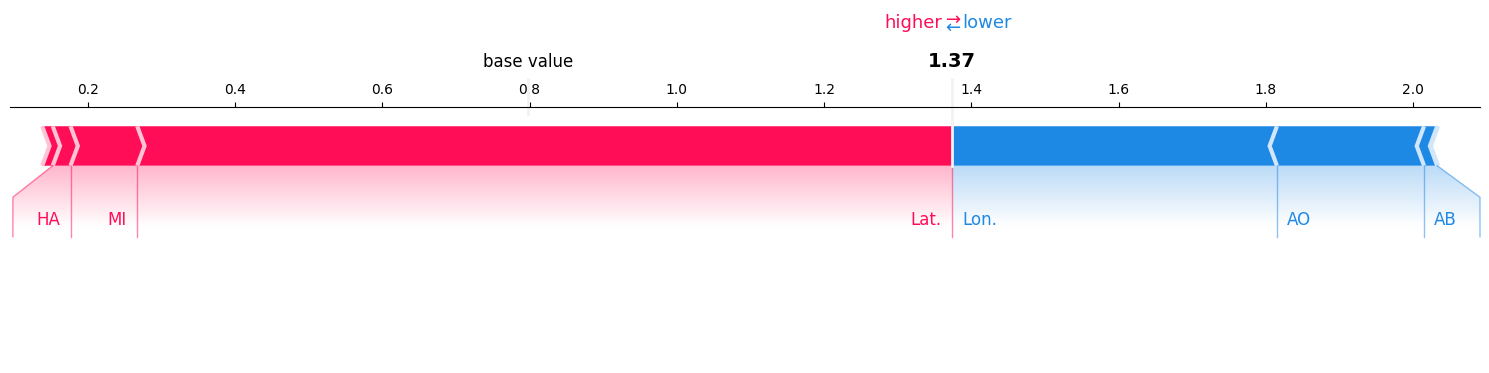

Computing pairwise Shapley interactions (k-SII)...


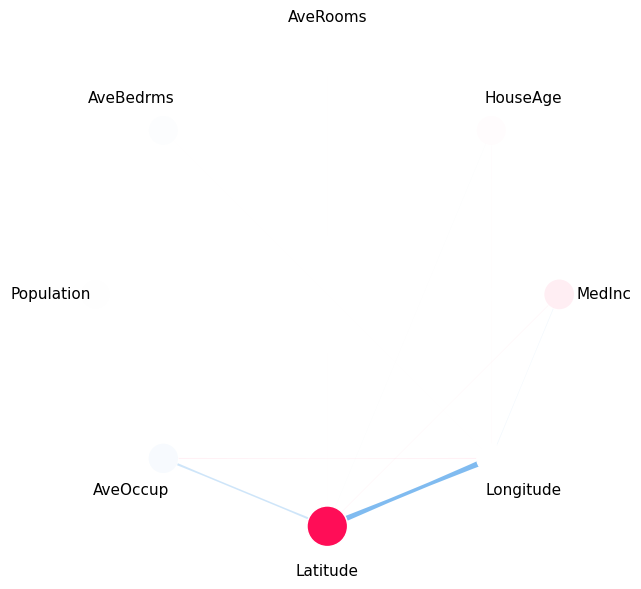

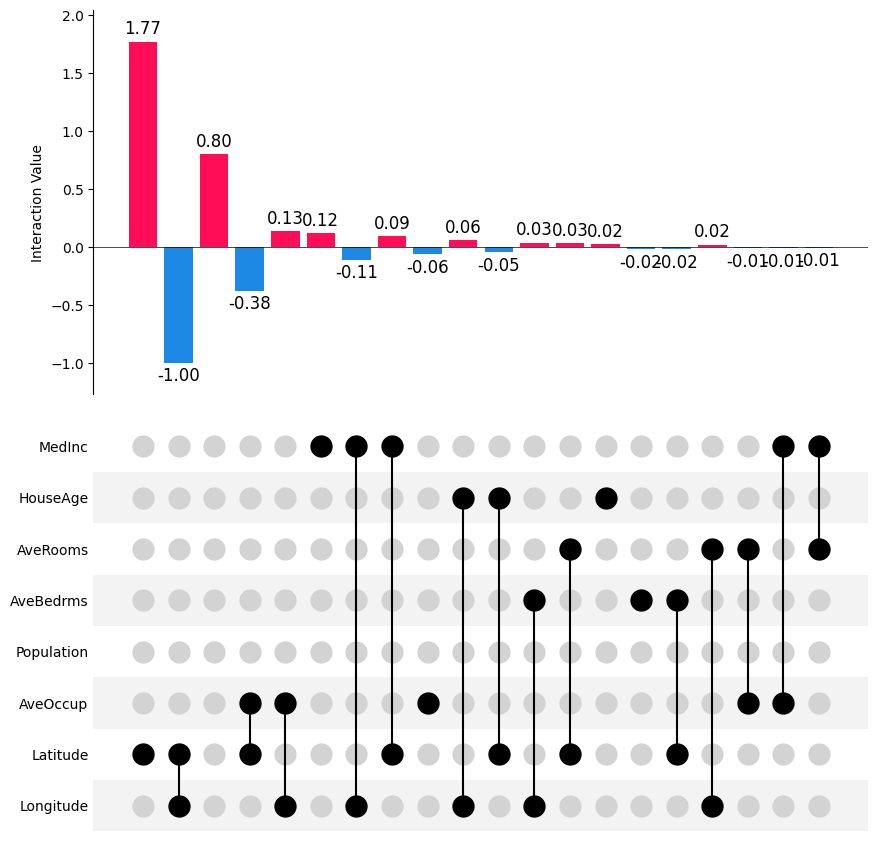

In [6]:
"""Compute Shapley values and pairwise Shapley interactions for a TabPFN model
using the ShapIQ library, and visualize them with shapiq's native plots.

Two paradigms for "feature removal" are illustrated:

  1. Imputation-based (`get_tabpfn_imputation_explainer`): masked features are
     filled by an imputer (default: baseline). The baseline imputer models
     missing values by the mean of the training set for numeric features
     and the mode for categorical features. The training set is fixed
     across coalitions, so the KV-cache fast path applies — make sure
     to construct the model with `fit_mode="fit_with_cache"`.

  2. Remove-and-recontextualize (`get_tabpfn_explainer`): TabPFN is re-fit on
     each coalition's column subset. Does not benefit from the KV cache
     (one predict per fit).

Dataset: California housing (regression, d=8).
"""

from __future__ import annotations

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

from tabpfn_extensions import TabPFNRegressor
from tabpfn_extensions.interpretability import shapiq as tabpfn_shapiq

housing = fetch_california_housing(as_frame=False)
X, y, feature_names = housing.data, housing.target, list(housing.feature_names)

X_train, X_test, y_train, _ = train_test_split(
    X, y, train_size=1000, test_size=200, random_state=0,
)
x_explain = X_test[0]

# Construct the regressor with the KV cache fast path. fit_mode must be set
# BEFORE .fit().
reg = TabPFNRegressor(fit_mode="fit_with_cache")
reg.fit(X_train, y_train)

# Exact enumeration for d=8 is 2**8 = 256 coalitions.
budget = 256


# -----------------------------------------------------------------------------
# 1. Imputation-based explainer (uses the KV cache)
# -----------------------------------------------------------------------------
imputation_explainer = tabpfn_shapiq.get_tabpfn_imputation_explainer(
    model=reg,
    data=X_train,
    index="SV",     # plain Shapley values
    max_order=1,
)
print("Computing imputation-based Shapley values...")
sv_imp = imputation_explainer.explain(x=x_explain, budget=budget)
sv_imp.plot_force(feature_names=feature_names)


# -----------------------------------------------------------------------------
# 2. Pairwise Shapley interactions via the same explainer (k-SII at max_order=2)
# -----------------------------------------------------------------------------
interaction_explainer = tabpfn_shapiq.get_tabpfn_imputation_explainer(
    model=reg,
    data=X_train,
    index="k-SII",  # k-Shapley Interaction Index — extends SHAP to interactions
    max_order=2,
)
print("Computing pairwise Shapley interactions (k-SII)...")
iv_interactions = interaction_explainer.explain(x=x_explain, budget=budget)

# Network plot: features as nodes, sized by individual SV; edges colored by
# pairwise interaction strength. Specific to shapiq (not in the shap library).
iv_interactions.plot_network(feature_names=feature_names)

# Upset plot of top interactions
iv_interactions.plot_upset(feature_names=feature_names)

# Result: Pairwise Shapley interactions uncover a strong interaction between
# Latitude and Longitude, which are not visible at lower orders.


# -----------------------------------------------------------------------------
# 3. Remove-and-recontextualize (Rundel) — slower (no KV cache)
# -----------------------------------------------------------------------------
# Commented out because this path is much slower than the imputation explainer
# above, as it doesn't benefit from the KV cache: each coalition
# triggers a fresh TabPFN fit on a different column subset, then does exactly
# one predict against that fit.
#
#     rundel_explainer = tabpfn_shapiq.get_tabpfn_explainer(
#         model=reg,
#         data=X_train,
#         labels=y_train,
#         index="SV",
#         max_order=1,
#     )
#     sv_rundel = rundel_explainer.explain(x=x_explain, budget=budget)
#     sv_rundel.plot_force(feature_names=feature_names)